# Titanic Data set Analysis

In [58]:
git status

SyntaxError: invalid syntax (3528599804.py, line 1)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style = "dark")

First we need to import the data set into the Jupyter notebook

In [6]:
# how to innitalise a dataframe(df) via pandas, a ds is a 2D array. 
df = pd.read_csv("Titanic-Dataset.csv")

#This is usful to see how big our data set is 
print(f" The size of this data set is: {df.shape} (rows x columns)" )

#This shows us the first 10 entires, if we did df.head() it would give the first 5.
#This is pretty useful when starting analysis on a dataset. df.tails() gives last 5
df.head(10)

 The size of this data set is: (891, 12) (rows x columns)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# Dataset Overview

In [7]:
#gives us info of: size, #columns, column names, non-null entries per column, dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# staistically summarises each column, but this is not for columns with sting values
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# for sting values, using pandas turns the stings into object values
df.describe(include = "object") 

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


# Missing Value Analysis

In [10]:
#We use isna() method to check if an element is missing/Na for every element in the df
print(df.isna())

#this will show then number of missing data per column 
df.isna().sum()

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
missingdf = pd.DataFrame({
    "missing count" : df.isna().sum(),
    "missing %" : ((df.isna().sum()/ df.shape[0]) *100).round(2)
})
missingdf

,missing count,missing %
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


Now lets use matplotlib to create graphs for this data

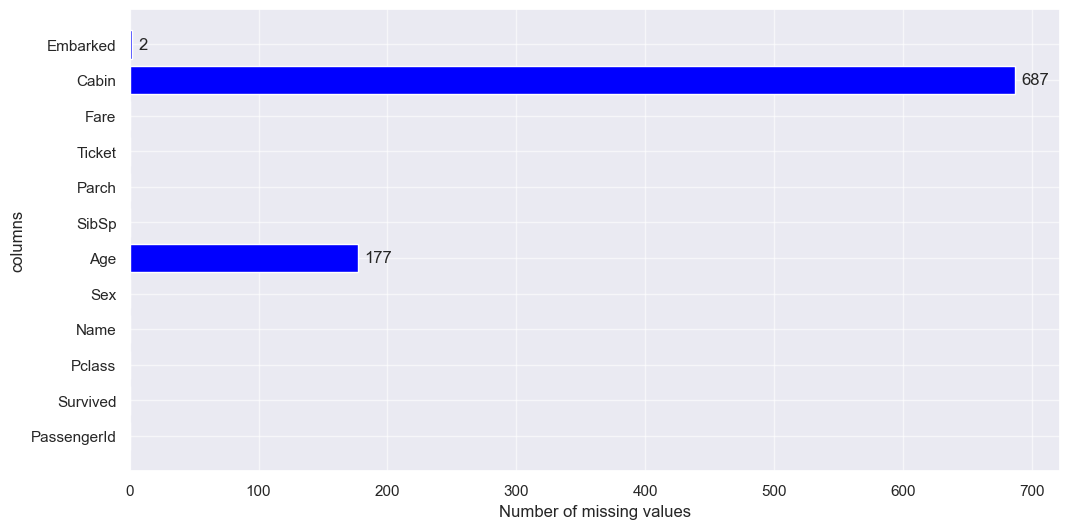

In [12]:
plt.figure(figsize = (12,6))
plt.barh(df.columns,df.isna().sum(), color = 'blue')
plt.ylabel('columns')
plt.xlabel('Number of missing values')

for i,v in enumerate(df.isna().sum()):
    if v > 0:
        plt.text(v+5,i,v, va = "center") # (x-coord,y-coord, center, vertical allignment)

plt.grid(True, alpha = 0.6)
plt.show()


# Target Value Analysis

In [13]:
#using pandas to create a series of wheter people survived, 0 = no, 1 = yes, .value_counts() adds upp all of the differnt sub categories in a column 
survived = df["Survived"].value_counts()
survived


Survived
0    549
1    342
Name: count, dtype: int64

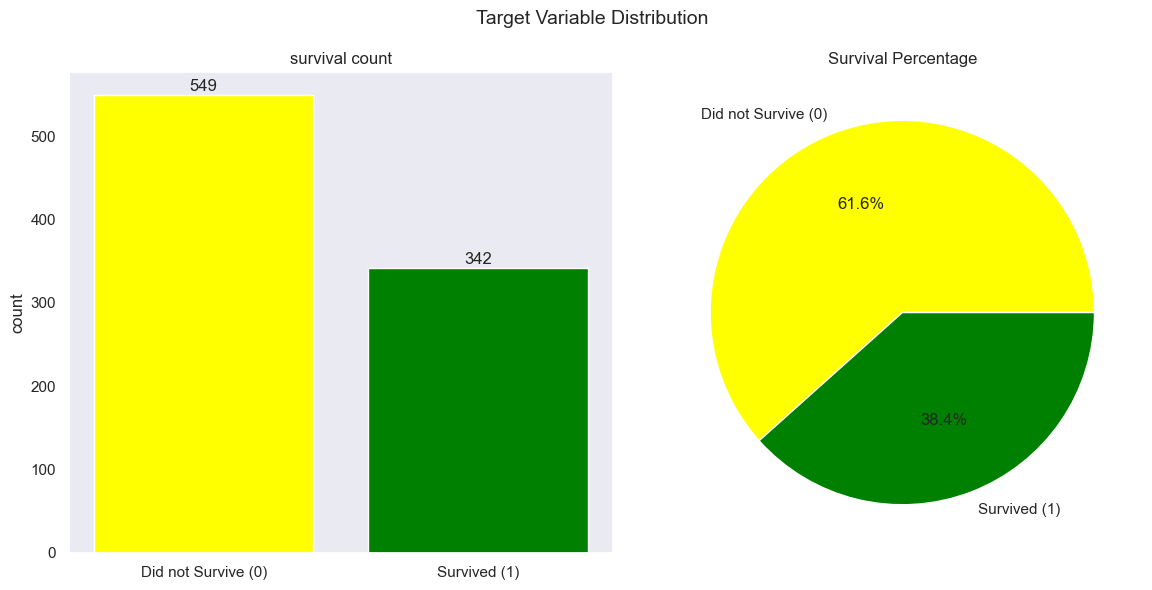

In [14]:
x = ['Did not Survive (0)', 'Survived (1)']
y = survived.values

fig,axes = plt.subplots(1,2, figsize = (12,6)) # (r,c) tells me i have r rows with c plots
axes[0].bar(x,y, color = ['yellow','green'])
axes[0].set_ylabel('count')
axes[0].set_title('survival count')
for i,count in enumerate(survived):
    axes[0].text(i, count+5,count, ha = 'center')

axes[1].pie(y, labels = x, autopct="%1.1f%%",colors = ['yellow','green'] )
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14)
plt.tight_layout()


# Univariate Analysis

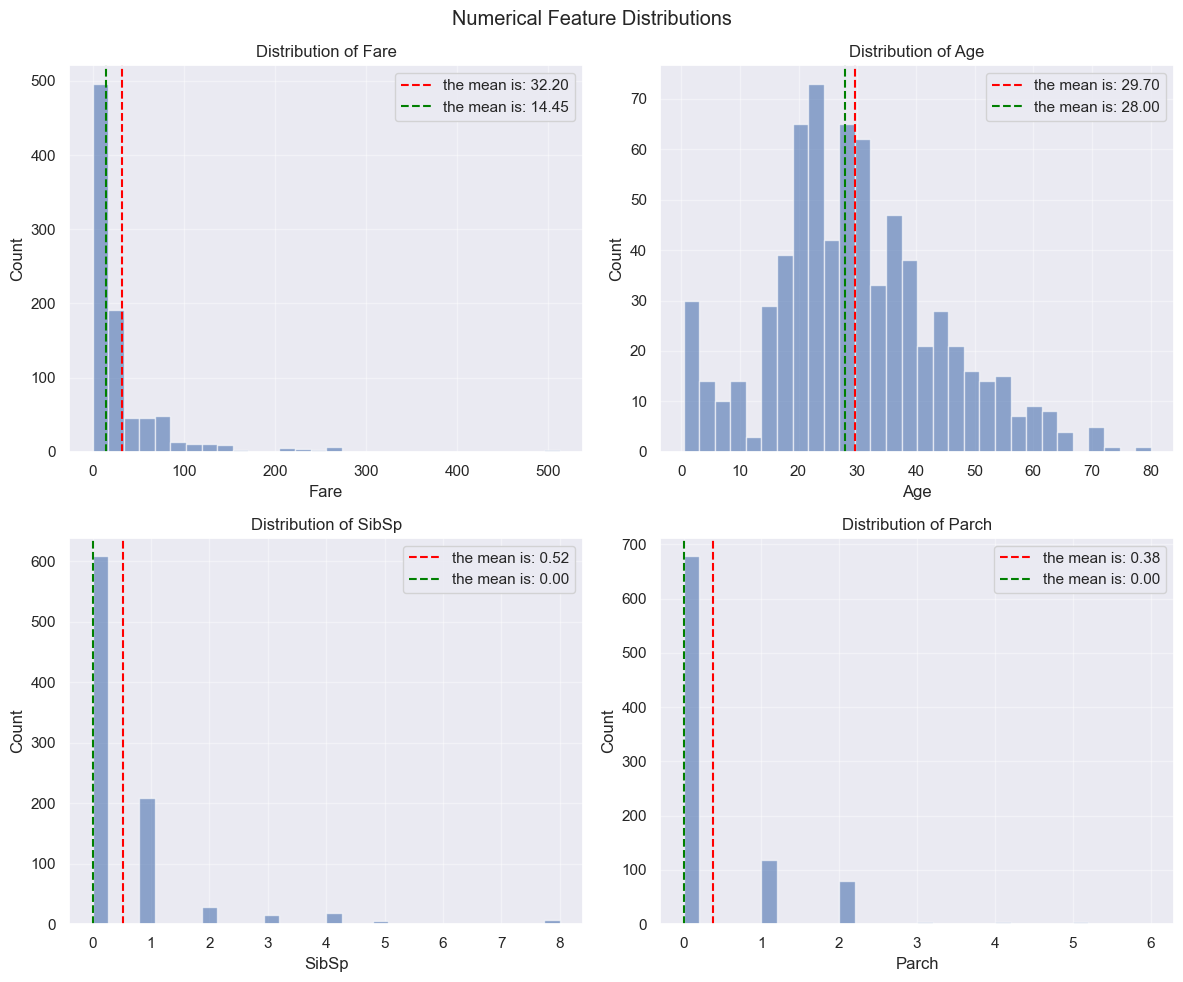

In [54]:
x = ["Fare", "Age", "SibSp","Parch"]
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()                                                                                             #.flaten turns the 3d axess in to 1d 
for i,col in enumerate(x):
    axes[i].hist(df[col].dropna(), bins = 30, alpha =0.6)                                                         #.dropna() removes na terms
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(f"{col}")
    axes[i].axvline(df[col].mean(), color = 'red', linestyle='--',label = f"the mean is: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color = 'green', linestyle='--',label = f"the mean is: {df[col].median():.2f}")   # :.2f ounds to 2 dp
    axes[i].set_ylabel("Count")
    axes[i].legend()
    axes[i].grid(True, alpha = 0.4)
    
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

## We can also make a boxplot

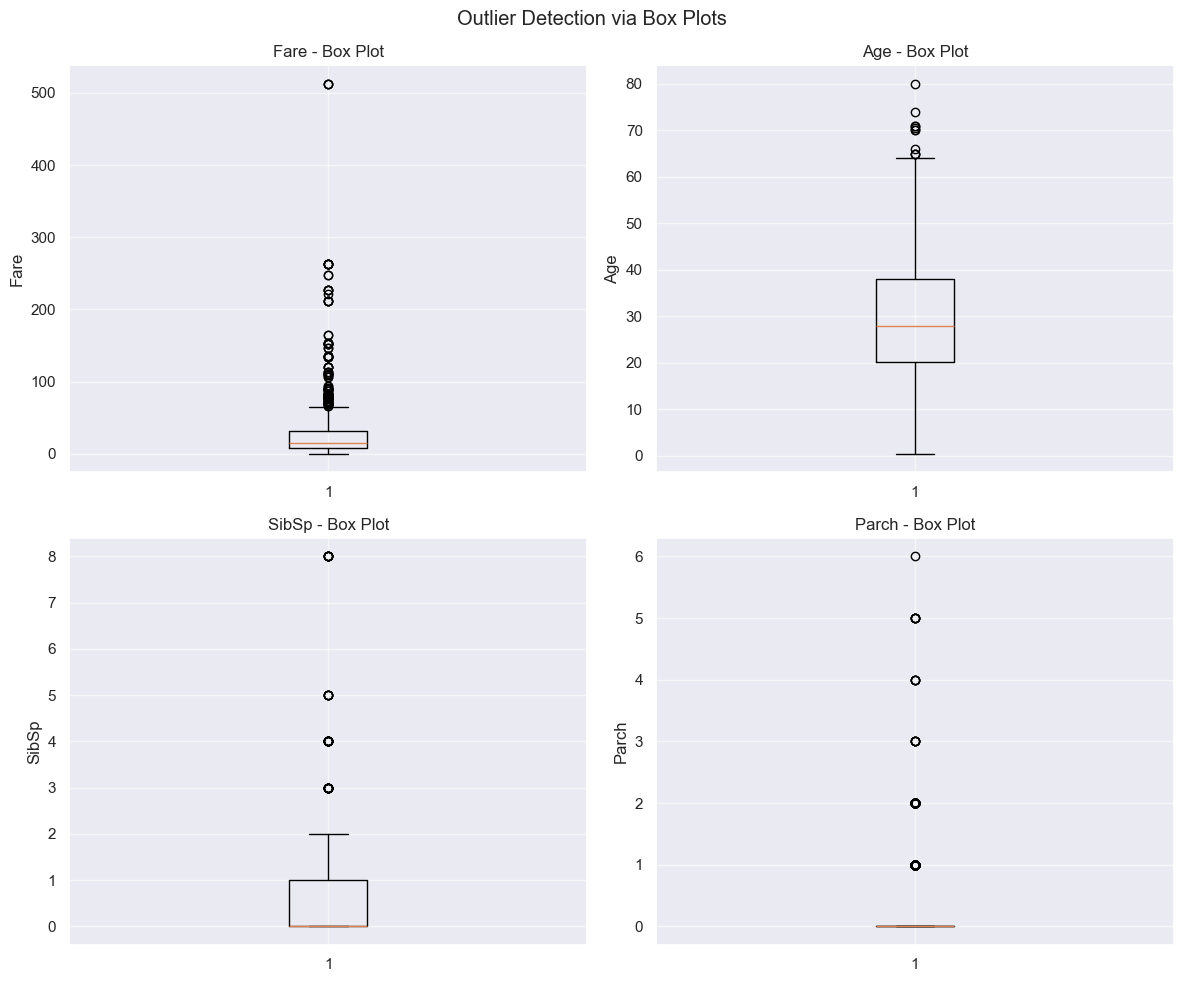

In [57]:
x = ["Fare", "Age", "SibSp","Parch"]
fig,axes = plt.subplots(2,2, figsize = (12,10))
axes = axes.flatten()

for i, col in enumerate(x):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col} - Box Plot')
    axes[i].set_ylabel(f"{col}")
    axes[i].grid(True, alpha = 0.6)

plt.suptitle("Outlier Detection via Box Plots")
plt.tight_layout()
plt.show()